In [8]:
!unzip "archive (12).zip"

Archive:  archive (12).zip
  inflating: annotations/potholes0.xml  
  inflating: annotations/potholes1.xml  
  inflating: annotations/potholes10.xml  
  inflating: annotations/potholes100.xml  
  inflating: annotations/potholes101.xml  
  inflating: annotations/potholes102.xml  
  inflating: annotations/potholes103.xml  
  inflating: annotations/potholes104.xml  
  inflating: annotations/potholes105.xml  
  inflating: annotations/potholes106.xml  
  inflating: annotations/potholes107.xml  
  inflating: annotations/potholes108.xml  
  inflating: annotations/potholes109.xml  
  inflating: annotations/potholes11.xml  
  inflating: annotations/potholes110.xml  
  inflating: annotations/potholes111.xml  
  inflating: annotations/potholes112.xml  
  inflating: annotations/potholes113.xml  
  inflating: annotations/potholes114.xml  
  inflating: annotations/potholes115.xml  
  inflating: annotations/potholes116.xml  
  inflating: annotations/potholes117.xml  
  inflating: annotations/potholes

In [9]:
!ls


 annotations  'archive (12).zip'   images   sample_data


In [12]:
import os

os.makedirs("/content/labels",exist_ok=True)

In [13]:
import xml.etree.ElementTree as ET
import os
from PIL import Image

images_path = "/content/images"
annotations_path = "/content/annotations"
labels_path = "/content/labels"

for xml_file in os.listdir(annotations_path):

    tree = ET.parse(os.path.join(annotations_path, xml_file))
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_path, filename)

    img = Image.open(image_path)
    w, h = img.size

    label_file = open(os.path.join(labels_path, xml_file.replace(".xml",".txt")), "w")

    for obj in root.findall("object"):

        class_id = 0  # pothole class

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / w
        y_center = ((ymin + ymax) / 2) / h
        width = (xmax - xmin) / w
        height = (ymax - ymin) / h

        label_file.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

    label_file.close()

In [14]:
import os

os.makedirs("dataset/train/images", exist_ok=True)
os.makedirs("dataset/train/labels", exist_ok=True)

os.makedirs("dataset/val/images", exist_ok=True)
os.makedirs("dataset/val/labels", exist_ok=True)

In [15]:
data = """
path: /content/dataset

train: train/images
val: val/images

names:
  0: pothole
"""

with open("data.yaml", "w") as f:
    f.write(data)


In [16]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.3 MB/s eta 0:00:00


In [19]:
from ultralytics import YOLO
import os
import shutil
from sklearn.model_selection import train_test_split

# --- Data preparation steps to populate train and val directories ---

images_dir = "/content/images"
labels_dir = "/content/labels"

train_images_dir = "dataset/train/images"
train_labels_dir = "dataset/train/labels"
val_images_dir = "dataset/val/images"
val_labels_dir = "dataset/val/labels"

# Ensure target directories exist (already created, but good for robustness)
os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)
os.makedirs(val_images_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

# Get all image files and construct corresponding label file paths
all_image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

existing_image_label_pairs = []
for img_file in all_image_files:
    base_name = os.path.splitext(img_file)[0]
    label_file = base_name + ".txt"
    if os.path.exists(os.path.join(labels_dir, label_file)): # Only include pairs where label exists
        existing_image_label_pairs.append((img_file, label_file))

# Split data into training and validation sets (e.g., 80% train, 20% val)
train_ratio = 0.8
train_pairs, val_pairs = train_test_split(existing_image_label_pairs, test_size=1-train_ratio, random_state=42)

print(f"Total image-label pairs found: {len(existing_image_label_pairs)}")
print(f"Training pairs: {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")

# Copy files to train directories
for img_file, label_file in train_pairs:
    shutil.copy(os.path.join(images_dir, img_file), os.path.join(train_images_dir, img_file))
    shutil.copy(os.path.join(labels_dir, label_file), os.path.join(train_labels_dir, label_file))

# Copy files to val directories
for img_file, label_file in val_pairs:
    shutil.copy(os.path.join(images_dir, img_file), os.path.join(val_images_dir, img_file))
    shutil.copy(os.path.join(labels_dir, label_file), os.path.join(val_labels_dir, label_file))

print("Data successfully split and copied to dataset/train and dataset/val directories.")

# --- End of data preparation steps ---

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640
)


Total image-label pairs found: 665
Training pairs: 532
Validation pairs: 133
Data successfully split and copied to dataset/train and dataset/val directories.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aba2c16e8d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [22]:
import os

# Get one image from the validation set for prediction
# The 'val_pairs' variable from the previous cell contains image-label pairs for validation.
# We can use the first image from this list.
if val_pairs:
    sample_image_filename = val_pairs[0][0] # Get the image filename from the first pair
    sample_image_path = os.path.join(val_images_dir, sample_image_filename)
    print(f"Attempting to predict on image: {sample_image_path}")
    model.predict(sample_image_path, save=True)
else:
    print("No validation images found to perform prediction.")

Attempting to predict on image: dataset/val/images/potholes166.png

image 1/1 /content/dataset/val/images/potholes166.png: 640x640 1 pothole, 7.2ms
Speed: 2.4ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [26]:
!ls runs/detect/train

args.yaml  weights


In [29]:
from ultralytics import YOLO

model = YOLO("runs/detect/train2/weights/best.pt")

# Ensure sample_image_path is defined, assuming it exists from previous successful prediction
# For robustness, we can re-create a sample path if needed, but for now we'll assume it's in scope.
# If this cell is run independently, you might need to define sample_image_path again.
# Using the previously defined 'sample_image_path' from cell nOUew_PUu9JN

if 'sample_image_path' in locals() and os.path.exists(sample_image_path):
    print(f"Attempting to predict on image: {sample_image_path}")
    model.predict(sample_image_path, save=True, conf=0.25)
else:
    print("Error: sample_image_path not found or does not exist. Please ensure an image path is available.")
    print("You might need to re-run the cell that defines 'sample_image_path' if running this cell in isolation.")


Attempting to predict on image: dataset/val/images/potholes166.png

image 1/1 /content/dataset/val/images/potholes166.png: 640x640 1 pothole, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


Contents of runs/detect/predict:
['potholes166.jpg']
Attempting to display: runs/detect/predict/potholes166.jpg


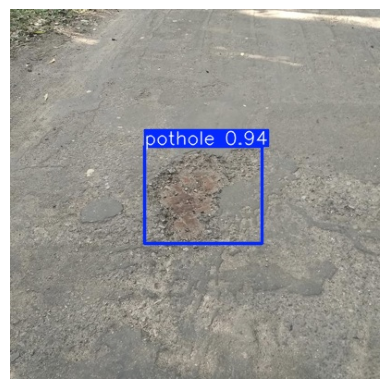

In [32]:
import cv2
import matplotlib.pyplot as plt
import os

# Assuming the last prediction was saved to runs/detect/predict
predict_dir = "runs/detect/predict"

# List contents of the directory to find the actual image file
print(f"Contents of {predict_dir}:")
predicted_files = os.listdir(predict_dir)
print(predicted_files)

# Find the first image file in the directory (assuming it's the predicted image)
predicted_image_file = None
for f in predicted_files:
    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
        predicted_image_file = f
        break

if predicted_image_file:
    image_path = os.path.join(predict_dir, predicted_image_file)
    print(f"Attempting to display: {image_path}")
    img = cv2.imread(image_path)
    if img is not None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not load image from {image_path}. It might be corrupted or unreadable.")
else:
    print(f"Error: No image file found in {predict_dir} to display.")


In [34]:
from google.colab import files
files.download("runs/detect/train2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>